<style>
/* Typography-only update: no text content changes */
.jp-RenderedHTMLCommon,
.jp-RenderedMarkdown,
.jp-MarkdownOutput {
  font-family: "Palatino Linotype", "Book Antiqua", Palatino, "Times New Roman", serif;
  line-height: 1.6;
  letter-spacing: 0.1px;
}

.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.jp-RenderedMarkdown h1,
.jp-RenderedMarkdown h2,
.jp-RenderedMarkdown h3 {
  font-family: "Segoe UI", "Trebuchet MS", "Gill Sans", sans-serif;
  font-weight: 700;
  letter-spacing: 0.2px;
}

.jp-RenderedHTMLCommon code,
.jp-RenderedMarkdown code,
.jp-RenderedHTMLCommon pre,
.jp-RenderedMarkdown pre {
  font-family: Consolas, "Cascadia Mono", "Courier New", monospace;
}
</style>

# 2) Feature Engineering

    Academic objectives
2.3 Create new features to improve model performance.

2.4 Mitigate the risk of biased features and accelerate convergence of some algorithms.

    Notebook
Analyze the available data columns in order to extract the best features from them, improving the model inputs. Basically following these 5 steps.

1. Target variable creation: Using GPS we will create the "status" variable and then protect these columns so they are not removed during the variance and correlation analysis (Although rows can still be removed)

2. Impute missing data.

3. Removal of Low Variance columns: For the initial development of features, a simple range normalization [0 1] will be applied

4. PCA

5. Save data into Parquet: Both features dataframe and PCA dataframe to decide the best option later during training. 

In [1]:
import re
import time
import warnings
from datetime import date

import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

import sc2_data as sc2


from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

# Download data from API

# Feature Engineering

In [3]:
# Restart df
df = df_raw.to_pandas()

# Verificación rápida del rango temporal
ts_min, ts_max = df["GLOBAL_TIME"].min(), df["GLOBAL_TIME"].max()
print(f"Rango GLOBAL_TIME: {ts_min}  →  {ts_max}")

df.head(3)

Rango GLOBAL_TIME: 2026-02-01 00:00:00.029001  →  2026-02-03 23:06:25.513000


,GLOBAL_TIME,___valve_lift_percent,___valve_tilt_percent,AIC_Active_Stat,Air_Filter_Restr_1,Air_Filter_Restr_2,AIR_INLET_TMP,ATMPRES,ave_cyl_flow,BATT_VOLT_ENG,...,Tout_torq_conv_ratio,TQ_TC_IN,Trans EDDT Diags (CDL),Trans EDDT Events (CDL),Trans SW Group Part Number (CDL),TransFNR,VEL_LIFT_CYL,VEL_TILT_CYL,vol_eff,vol_eff_valid
0,2026-02-01 00:00:00.029001,0.0,0.0,0.0,1.59375,1.4375,35.5,99.78125,0.0,27.85,...,0.608,1690.0,0.0,0.0,0.0,56.0,0.0,0.0,65536.0,0.0
1,2026-02-01 00:00:00.149000,0.0,0.0,0.0,1.50000,1.4375,35.5,99.78125,0.0,27.85,...,0.608,1601.0,0.0,0.0,0.0,56.0,0.0,0.0,65536.0,0.0
2,2026-02-01 00:00:00.269000,0.0,0.0,0.0,1.50000,1.4375,35.5,99.78125,0.0,27.85,...,0.618,1559.0,0.0,0.0,0.0,56.0,0.0,0.0,65536.0,0.0


### 1 - Use of GPS for target variable creation
Before creating labels, there is a native issue with GPS, where the sensor can't lock in to a satellite, so the value is filled with a zero. If the fault was short duration, an interpolation could be applied, but since it usually takes a while to lock in again, I preferred to simply impute the 0 values

C:\Users\alvarjl3\AppData\Local\Temp\ipykernel_15436\1851636709.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


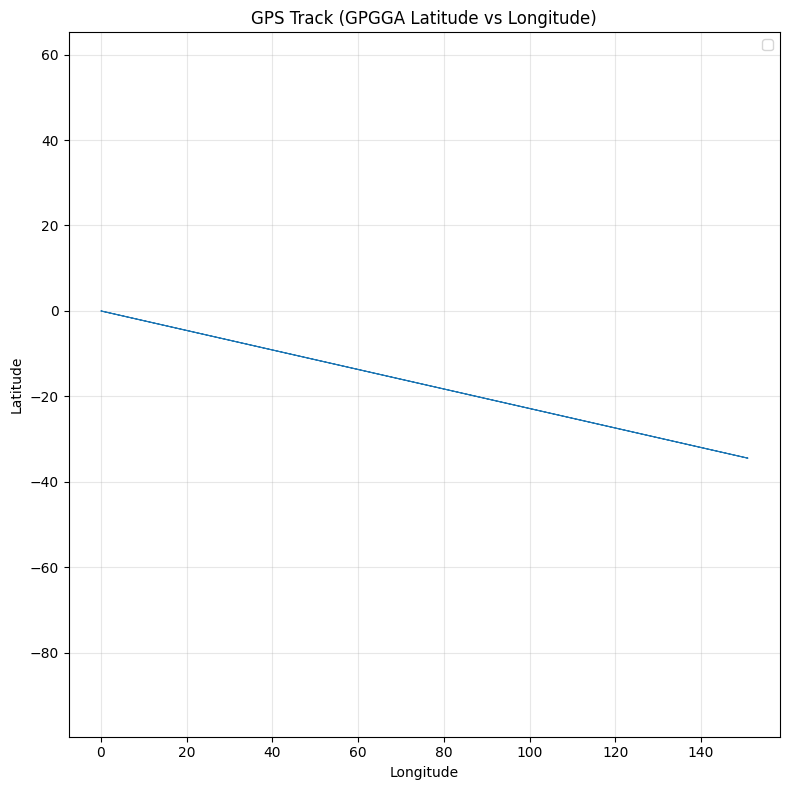

In [4]:
lat_col = "GPGGA Latitude"
lon_col = "GPGGA Longitude"

gps = df[[lat_col, lon_col]].dropna()

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(gps[lon_col], gps[lat_col], linewidth=0.8, color="tab:blue")
# ax.scatter(gps[lon_col].iloc[0], gps[lat_col].iloc[0], c="green", s=60, label="Start", zorder=5)
# ax.scatter(gps[lon_col].iloc[-1], gps[lat_col].iloc[-1], c="red", s=60, label="End", zorder=5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("GPS Track (GPGGA Latitude vs Longitude)")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


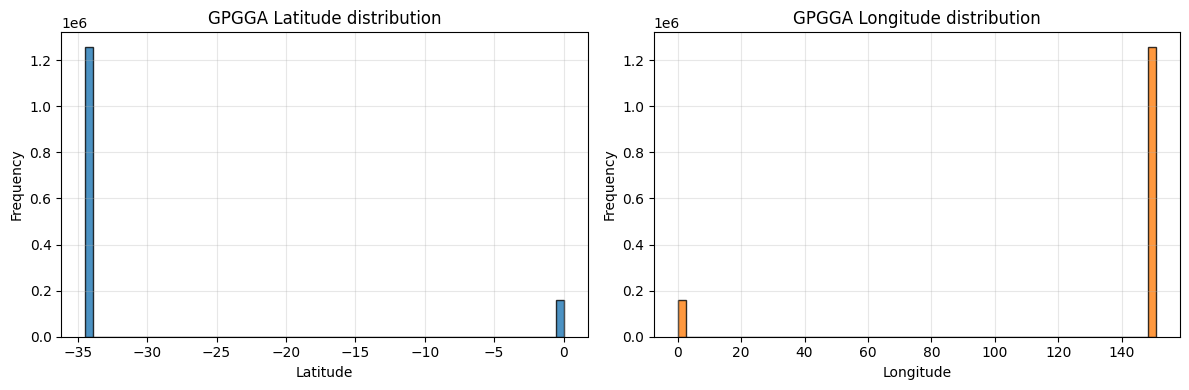

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gps[lat_col], bins=60, color="tab:blue", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Latitude")
axes[0].set_ylabel("Frequency")
axes[0].set_title("GPGGA Latitude distribution")
axes[0].grid(True, alpha=0.3)

axes[1].hist(gps[lon_col], bins=60, color="tab:orange", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Frequency")
axes[1].set_title("GPGGA Longitude distribution")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

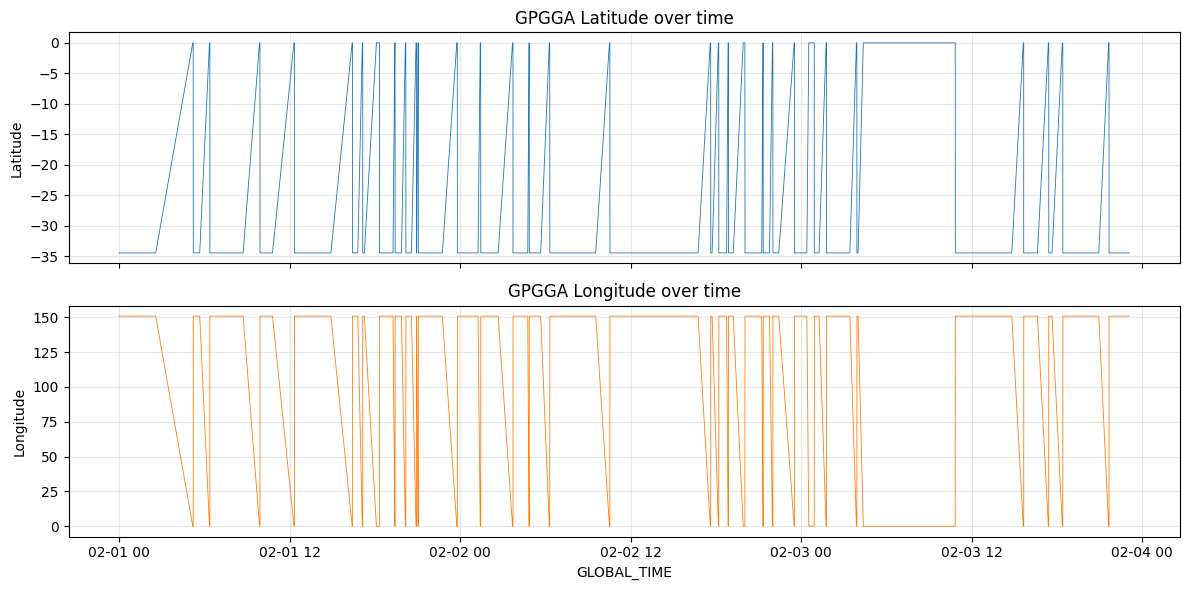

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df["GLOBAL_TIME"], df[lat_col], linewidth=0.6, color="tab:blue")
axes[0].set_ylabel("Latitude")
axes[0].set_title("GPGGA Latitude over time")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["GLOBAL_TIME"], df[lon_col], linewidth=0.6, color="tab:orange")
axes[1].set_ylabel("Longitude")
axes[1].set_xlabel("GLOBAL_TIME")
axes[1].set_title("GPGGA Longitude over time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
before = len(df)
mask = (df[lat_col] != 0) & (df[lon_col] != 0)
df = df[mask].reset_index(drop=True)
gps = df[[lat_col, lon_col]].dropna()
print(f"Removed {before - len(df)} rows with zero latitude/longitude")


Removed 158208 rows with zero latitude/longitude


### Label creation based on GPS using area segmentation

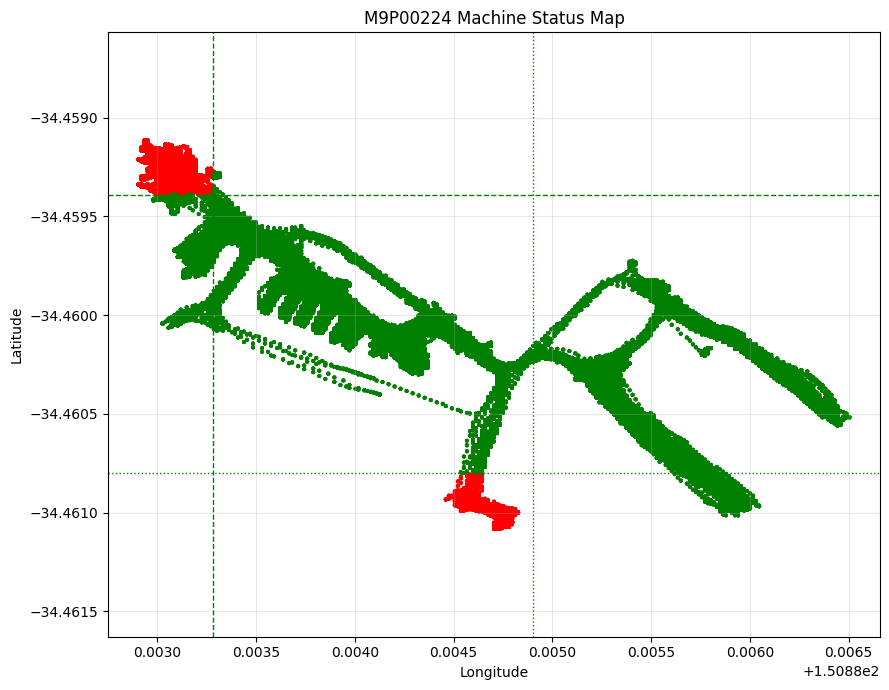


Class balance:
                  n      %
Status                    
working      985660  78.39
not_working  271713  21.61

Dropped GPS columns to prevent leakage: ['GPGGA Latitude', 'GPGGA Longitude']
PROTECTED_COLS now: ['GLOBAL_TIME', 'Status', 'date_time']

Final shape after labeling: (1257373, 299)


In [8]:

ref_lat,    ref_long    = -34.45939, 150.88328
ref_lat_w2, ref_long_w2 = -34.4608,  150.8849

lat = df[lat_col]
lon = df[lon_col]

not_working = (
    ((lat > ref_lat) & (lon < ref_long))
    | ((lat < ref_lat_w2) & (lon < ref_long_w2))
)
working = ~not_working

df["Status"] = np.select(
    [working.fillna(False), not_working.fillna(False)],
    ["working", "not_working"],
    default="other",
)


# --- Plot the resulting labels on the GPS map -------------------------------
GREEN, RED = (0.1, 0.9, 0.1), (1.0, 0.2, 0.2)
colors = np.where(df["Status"].eq("working"), "green", "red")

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df[lon_col], df[lat_col], s=8, c=colors, alpha=0.6, edgecolors="none")
ax.axvline(ref_long,    ls="--", color="green", lw=1)
ax.axhline(ref_lat,     ls="--", color="green", lw=1)
ax.axvline(ref_long_w2, ls=":",  color="green", lw=1)
ax.axhline(ref_lat_w2,  ls=":",  color="green", lw=1)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"{SERIAL_NUMBER} Machine Status Map")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Class balance ----------------------------------------------------------
counts = df["Status"].value_counts()
pct = (counts / counts.sum() * 100).round(2)
print("\nClass balance:")
print(pd.concat([counts.rename("n"), pct.rename("%")], axis=1).to_string())

# --- Drop GPS columns (used only for labeling; would cause data leakage) ----
GPS_COLS = [c for c in [lat_col, lon_col] if c in df.columns]
df = df.drop(columns=GPS_COLS)
print(f"\nDropped GPS columns to prevent leakage: {GPS_COLS}")

# --- Protect `Status` from being removed by downstream feature selectors ----
# Any later cell that scans columns must consult PROTECTED_COLS and skip them.
try:
    PROTECTED_COLS.add("Status")
except NameError:
    PROTECTED_COLS = {"date_time", "GLOBAL_TIME", "Status"}
print(f"PROTECTED_COLS now: {sorted(PROTECTED_COLS)}")

print(f"\nFinal shape after labeling: {df.shape}")


### NOTE: Keyswitch
While pitching this project, there has been a valid common concern. Can't you just tell if machine is active or not by looking at the keyswitch? Yes. But we can't know what lead to a keysitch. And for the looks of it, it doesn't seem to be related to the data. However, it is being considered to use keyswitch as "baseline" for model development

Using channel: keyswitch


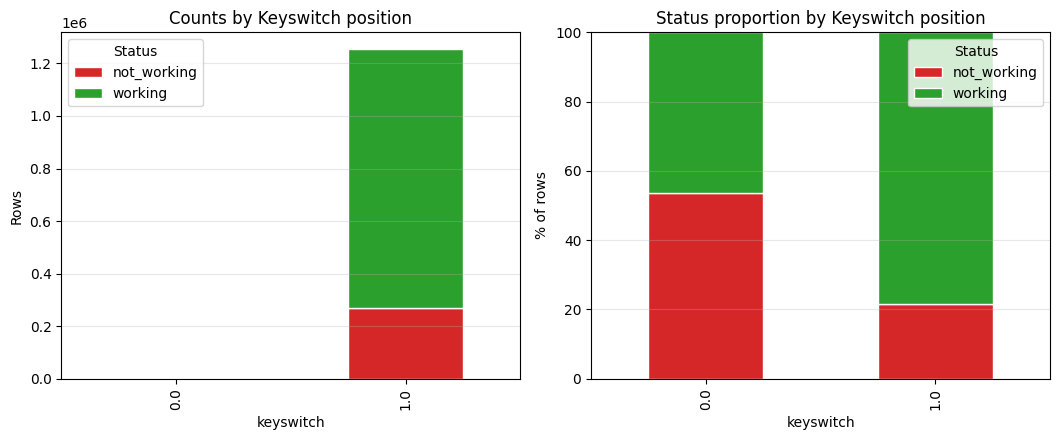

In [9]:
# Relationship between the "Keyswitch" channel and the target "Status".
# Keyswitch reports the ignition position (0 = off, 1 = accessory, 2 = run,
# 3 = start), so we expect "working" rows to concentrate on the run/start
# positions and "not_working" rows on off/accessory.

# Find the keyswitch column (name varies slightly across machines)
keyswitch_col = next(
    (c for c in df.columns if "keyswitch" in c.lower()),
    None,
)
if keyswitch_col is None:
    raise ValueError("No 'Keyswitch' channel found in df.columns")

print(f"Using channel: {keyswitch_col}")

ks = df[[keyswitch_col, "Status"]].dropna()

palette = {"working": "tab:green", "not_working": "tab:red"}
status_order = [s for s in ["not_working", "working"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) Stacked bar of counts per Keyswitch value
ct = (
    pd.crosstab(ks[keyswitch_col], ks["Status"])
      .reindex(columns=status_order, fill_value=0)
)

ct.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[palette[s] for s in status_order],
    edgecolor="white",
)

ct_pct = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
axes[0].set_title("Counts by Keyswitch position")
axes[0].set_xlabel(keyswitch_col)
axes[0].set_ylabel("Rows")
axes[0].legend(title="Status")
axes[0].grid(True, axis="y", alpha=0.3)

# (2) 100% stacked bar -> proportion of each Status per Keyswitch value
ct_pct[status_order].plot(
    kind="bar", stacked=True, ax=axes[1],
    color=[palette[s] for s in status_order], edgecolor="white",
)
axes[1].set_title("Status proportion by Keyswitch position")
axes[1].set_xlabel(keyswitch_col)
axes[1].set_ylabel("% of rows")
axes[1].set_ylim(0, 100)
axes[1].legend(title="Status")
axes[1].grid(True, axis="y", alpha=0.3)

# (3) Time series: Keyswitch over time, colored by Status
if "date_time" in df.columns:
    for lvl in status_order:
        m = ks.index[df.loc[ks.index, "Status"] == lvl]
        axes[2].scatter(
            df.loc[m, "date_time"], df.loc[m, keyswitch_col],
            s=4, alpha=0.5, color=palette[lvl], label=lvl,
        )
    axes[2].set_title("Keyswitch over time, coloured by Status")
    axes[2].set_xlabel("date_time")
    axes[2].set_ylabel(keyswitch_col)
    axes[2].legend(title="Status")
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].set_visible(False)

plt.tight_layout()
plt.show()


### 2 - Imputing missing data
It is common to have faulty channels or non-continuous channels for onboard software diagnostics. They will be removed

In [10]:
# Remove columns with more than 10% missing values
missing_ratio = df.isna().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.1].index.tolist()

print(f"Columns with >10% missing values: {len(cols_to_drop)}")
if cols_to_drop:
    print("Removed columns:")
    for col in cols_to_drop:
        print(f"- {col}")
else:
    print("Removed columns: none")

# Keep only columns with <=10% missing values
df = df.drop(columns=cols_to_drop)

print(f"Shape after dropping columns: {df.shape}")

# Drop any remaining rows that still contain NaN in any column
rows_before = len(df)
df = df.dropna(how="any").reset_index(drop=True)
rows_dropped = rows_before - len(df)
pct = (rows_dropped / rows_before * 100) if rows_before else 0.0
print(f"Dropped {rows_dropped} rows with any missing values "
      f"({pct:.2f}% of {rows_before}).")
print(f"Final shape: {df.shape}")


Columns with >10% missing values: 5
Removed columns:
- EDDT_CAN1_MID00_C298_F3_W1
- EDDT_CDL1_MID51_E1434_W1
- EDDT_CDL1_MID51_E490_W2
- EDDT_CDL1_MID52_C168_F4_W2
- EDDT_CDL1_MID52_E643_W1
Shape after dropping columns: (1257373, 294)
Dropped 0 rows with any missing values (0.00% of 1257373).
Final shape: (1257373, 294)


### 3 - Remove low Variance

0% Variance First. Several SW diagnostics channels that might nver be triggered (as well as broken channels)

Removed 131 zero-variance columns:
  - ave_cyl_flow  (constant value: 0)
  - bore_diameter  (constant value: 254)
  - CMD_AUTO_IDLE_KICKDOWN  (constant value: 0)
  - Comp_brake_actual_level  (constant value: 0)
  - Coolant_Lvl_Input  (constant value: 0)
  - ec_cac_out_temp  (constant value: 0)
  - EC_soi_press  (constant value: 0)
  - EDDT_CDL1_MID51_C168_F4_W1  (constant value: 12)
  - EDDT_CDL1_MID51_C590_F9_W1  (constant value: 12)
  - EDDT_CDL1_MID51_C596_F9_W1  (constant value: 12)
  - EDDT_CDL1_MID51_C623_F4_W1  (constant value: 12)
  - EDDT_CDL1_MID51_C70_F2_W3  (constant value: 12)
  - EDDT_CDL1_MID51_C967_F9_W2  (constant value: 12)
  - EDDT_CDL1_MID51_C96_F3_W1  (constant value: 12)
  - EDDT_CDL1_MID51_E1505_W2  (constant value: 12)
  - EDDT_CDL1_MID51_E2129_W2  (constant value: 12)
  - EDDT_CDL1_MID51_E2157_W1  (constant value: 12)
  - EDDT_CDL1_MID51_E234_W1  (constant value: 12)
  - EDDT_CDL1_MID51_E234_W2  (constant value: 12)
  - EDDT_CDL1_MID51_E334_W2  (constant value:

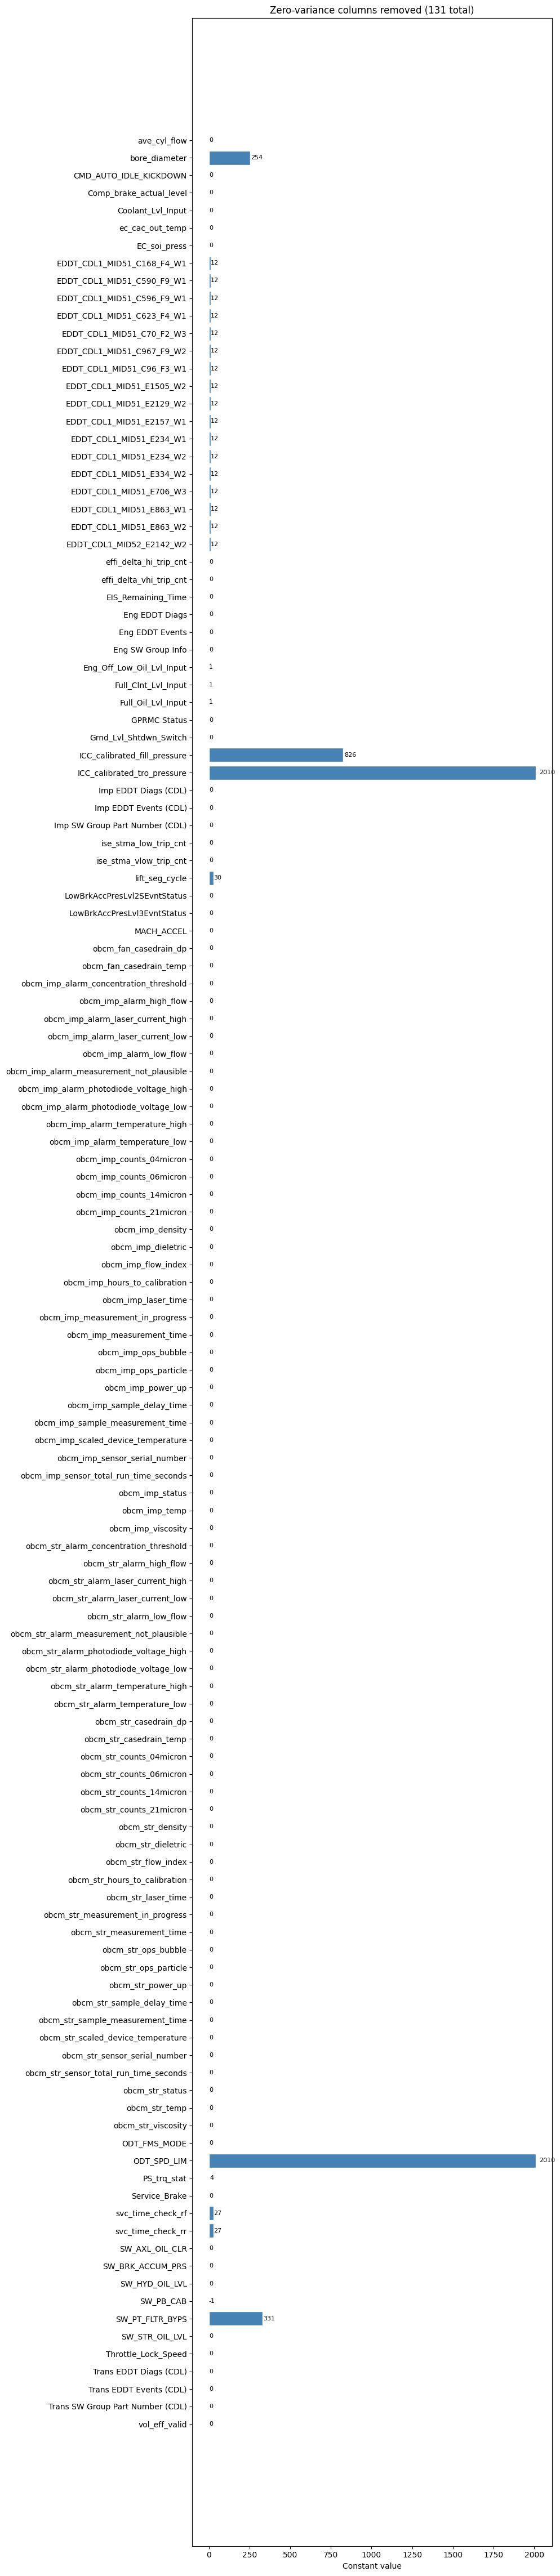

In [11]:
# Remove columns with 0% variance (skip protected columns such as the target)
zero_var_cols = [
    c for c in df.columns[df.nunique(dropna=False) <= 1].tolist()
    if c not in PROTECTED_COLS
]

if zero_var_cols:
    print(f"Removed {len(zero_var_cols)} zero-variance columns:")

    # Collect constant value per column (NaN if the column is entirely null)
    const_vals = [
        df[col].dropna().iloc[0] if df[col].notna().any() else float("nan")
        for col in zero_var_cols
    ]
    for col, val in zip(zero_var_cols, const_vals):
        label = "NaN" if pd.isna(val) else f"{val:.4g}"
        print(f"  - {col}  (constant value: {label})")

    # Visualize: horizontal bar chart of the constant value for each removed column
    zv_df = pd.DataFrame({"column": zero_var_cols, "constant_value": const_vals})

    fig, ax = plt.subplots(figsize=(10, max(4, len(zero_var_cols) * 0.35)))
    bars = ax.barh(zv_df["column"], zv_df["constant_value"].fillna(0),
                   color="steelblue", edgecolor="white")
    for bar, val in zip(bars, zv_df["constant_value"]):
        lbl = "NaN" if pd.isna(val) else f"{val:.4g}"
        ax.text(bar.get_width() + abs(bar.get_width()) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                lbl, va="center", fontsize=8)
    ax.set_xlabel("Constant value")
    ax.set_title(f"Zero-variance columns removed ({len(zero_var_cols)} total)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    df = df.drop(columns=zero_var_cols)
else:

    print("No zero-variance columns found.")


Then, less than 1% normalized variance (>1%). Other SW diagnostics channels change very few times. Also tryng to avoid operating condtions that stayed in the same position for long periods of times, like parking brake engagend, keyswitch, altitude, etc. 

Columns with <1% normalized variance: 36
Removed columns:
  - AIR_INLET_TMP  (normalized variance: 0.0097)
  - BATT_VOLT_ENG  (normalized variance: 0.0001)
  - BATT_VOLT_IMPL  (normalized variance: 0.0017)
  - BATT_VOLT_TRAN  (normalized variance: 0.0001)
  - Brake Accum Sensr Press1  (normalized variance: 0.0021)
  - CMD_PRCNT_RIMPULL  (normalized variance: 0.0000)
  - CMD_VLV_FLOAT  (normalized variance: 0.0002)
  - Coolant_Pressure_status  (normalized variance: 0.0015)
  - CUR_LUC  (normalized variance: 0.0003)
  - EC_ssm_number  (normalized variance: 0.0017)
  - ec_virtual_exh_temp  (normalized variance: 0.0012)
  - EDDT_CDL1_MID51_E155_W2  (normalized variance: 0.0001)
  - Eng_On_Low_Oil_Lvl_Input  (normalized variance: 0.0000)
  - Fan_Curr_Des  (normalized variance: 0.0005)
  - Fan_Perc_Bypass  (normalized variance: 0.0005)
  - GPGGA Altitude  (normalized variance: 0.0028)
  - GPRMC Date  (normalized variance: 0.0006)
  - key_switch  (normalized variance: 0.0012)
  - keyswitch  (

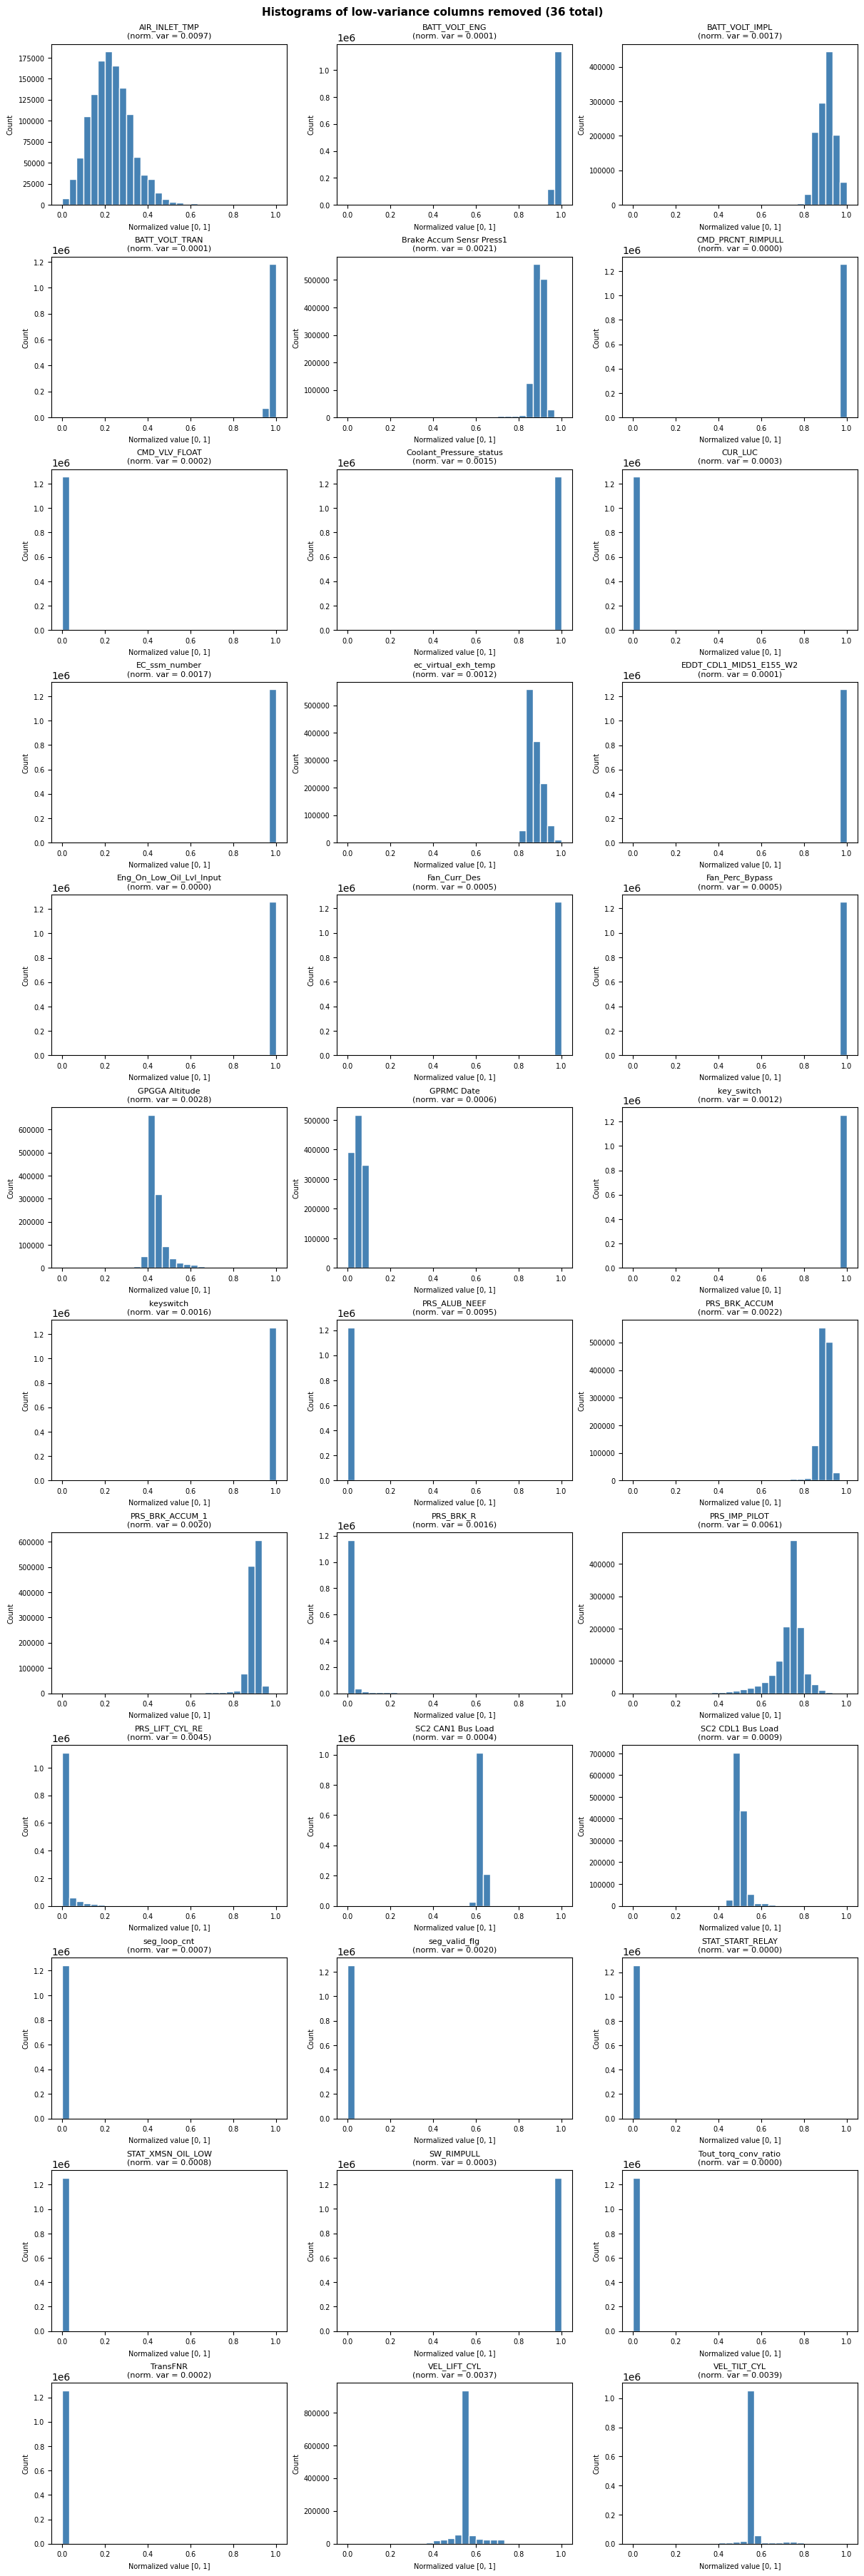

Shape after removal: (1257373, 127)


In [12]:
# 5% Variance
# Normalize to [0,1] so variance is comparable across channels with different scales
scaler = MinMaxScaler()
# Scale only numeric columns (exclude datetime/object columns like 'date_time')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols,
    index=df.index
)

# Remove columns whose normalized variance is below 1%
selector = VarianceThreshold(threshold=0.01)
selector.fit(df_scaled)

low_var_cols = [col for col, keep in zip(numeric_cols, selector.get_support()) if not keep]

print(f"Columns with <1% normalized variance: {len(low_var_cols)}")
if low_var_cols:
    print("Removed columns:")
    for col in low_var_cols:
        print(f"  - {col}  (normalized variance: {df_scaled[col].var():.4f})")

    # Histogram grid: one histogram per removed column (normalized scale)
    n_cols = 3
    n_rows = int(np.ceil(len(low_var_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 4, n_rows * 3),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, low_var_cols):
        ax.hist(df_scaled[col].dropna(), bins=30, color="steelblue", edgecolor="white")
        var_val = df_scaled[col].var()
        ax.set_title(f"{col}\n(norm. var = {var_val:.4f})", fontsize=8)
        ax.set_xlabel("Normalized value [0, 1]", fontsize=7)
        ax.set_ylabel("Count", fontsize=7)
        ax.tick_params(labelsize=7)

    # Hide unused subplots
    for ax in axes[len(low_var_cols):]:
        ax.set_visible(False)

    fig.suptitle(f"Histograms of low-variance columns removed ({len(low_var_cols)} total)",
                 fontsize=11, fontweight="bold")
    plt.show()

    df = df.drop(columns=low_var_cols)
else:
    print("No columns removed.")

print(f"Shape after removal: {df.shape}")


### 4 - Removal by correlation: +/- 80%


Pairs with |corr| > 0.8: 465
                          var_1                           var_2  abs_corr  signed_corr
                   ParkBrakeCmd                 ParkBrakeSolCmd  1.000000    -1.000000
          segment_lift_cyl_flow            segment_lift_cyl_vel  1.000000     1.000000
                RF_MAX_FLOW_PMP                 RR_MAX_FLOW_PMP  0.999930     0.999930
           INTAKE2_MAN_AIR_PRES             INTAKE_MAN_AIR_PRES  0.999925     0.999925
                    EC_est_tmef                         EC_fmaf  0.999886     0.999886
                     GROUND_SPD                    SPD_XMSN_OUT  0.999841    -0.999841
  ceal_sensor_temp_exhaust_left  ceal_sensor_temp_exhaust_left2  0.999779     0.999779
                PRS_IMPEL_CLTCH           Tin_IC_pressure_value  0.999694     0.999694
              brake_eng_spd_val               FLW_IMP_MAX_AVAIL  0.999663     0.999663
 ceal_sensor_temp_exhaust_left2  ceal_sensor_temp_exhaust_right  0.999652     0.999652
 ceal_sensor_t

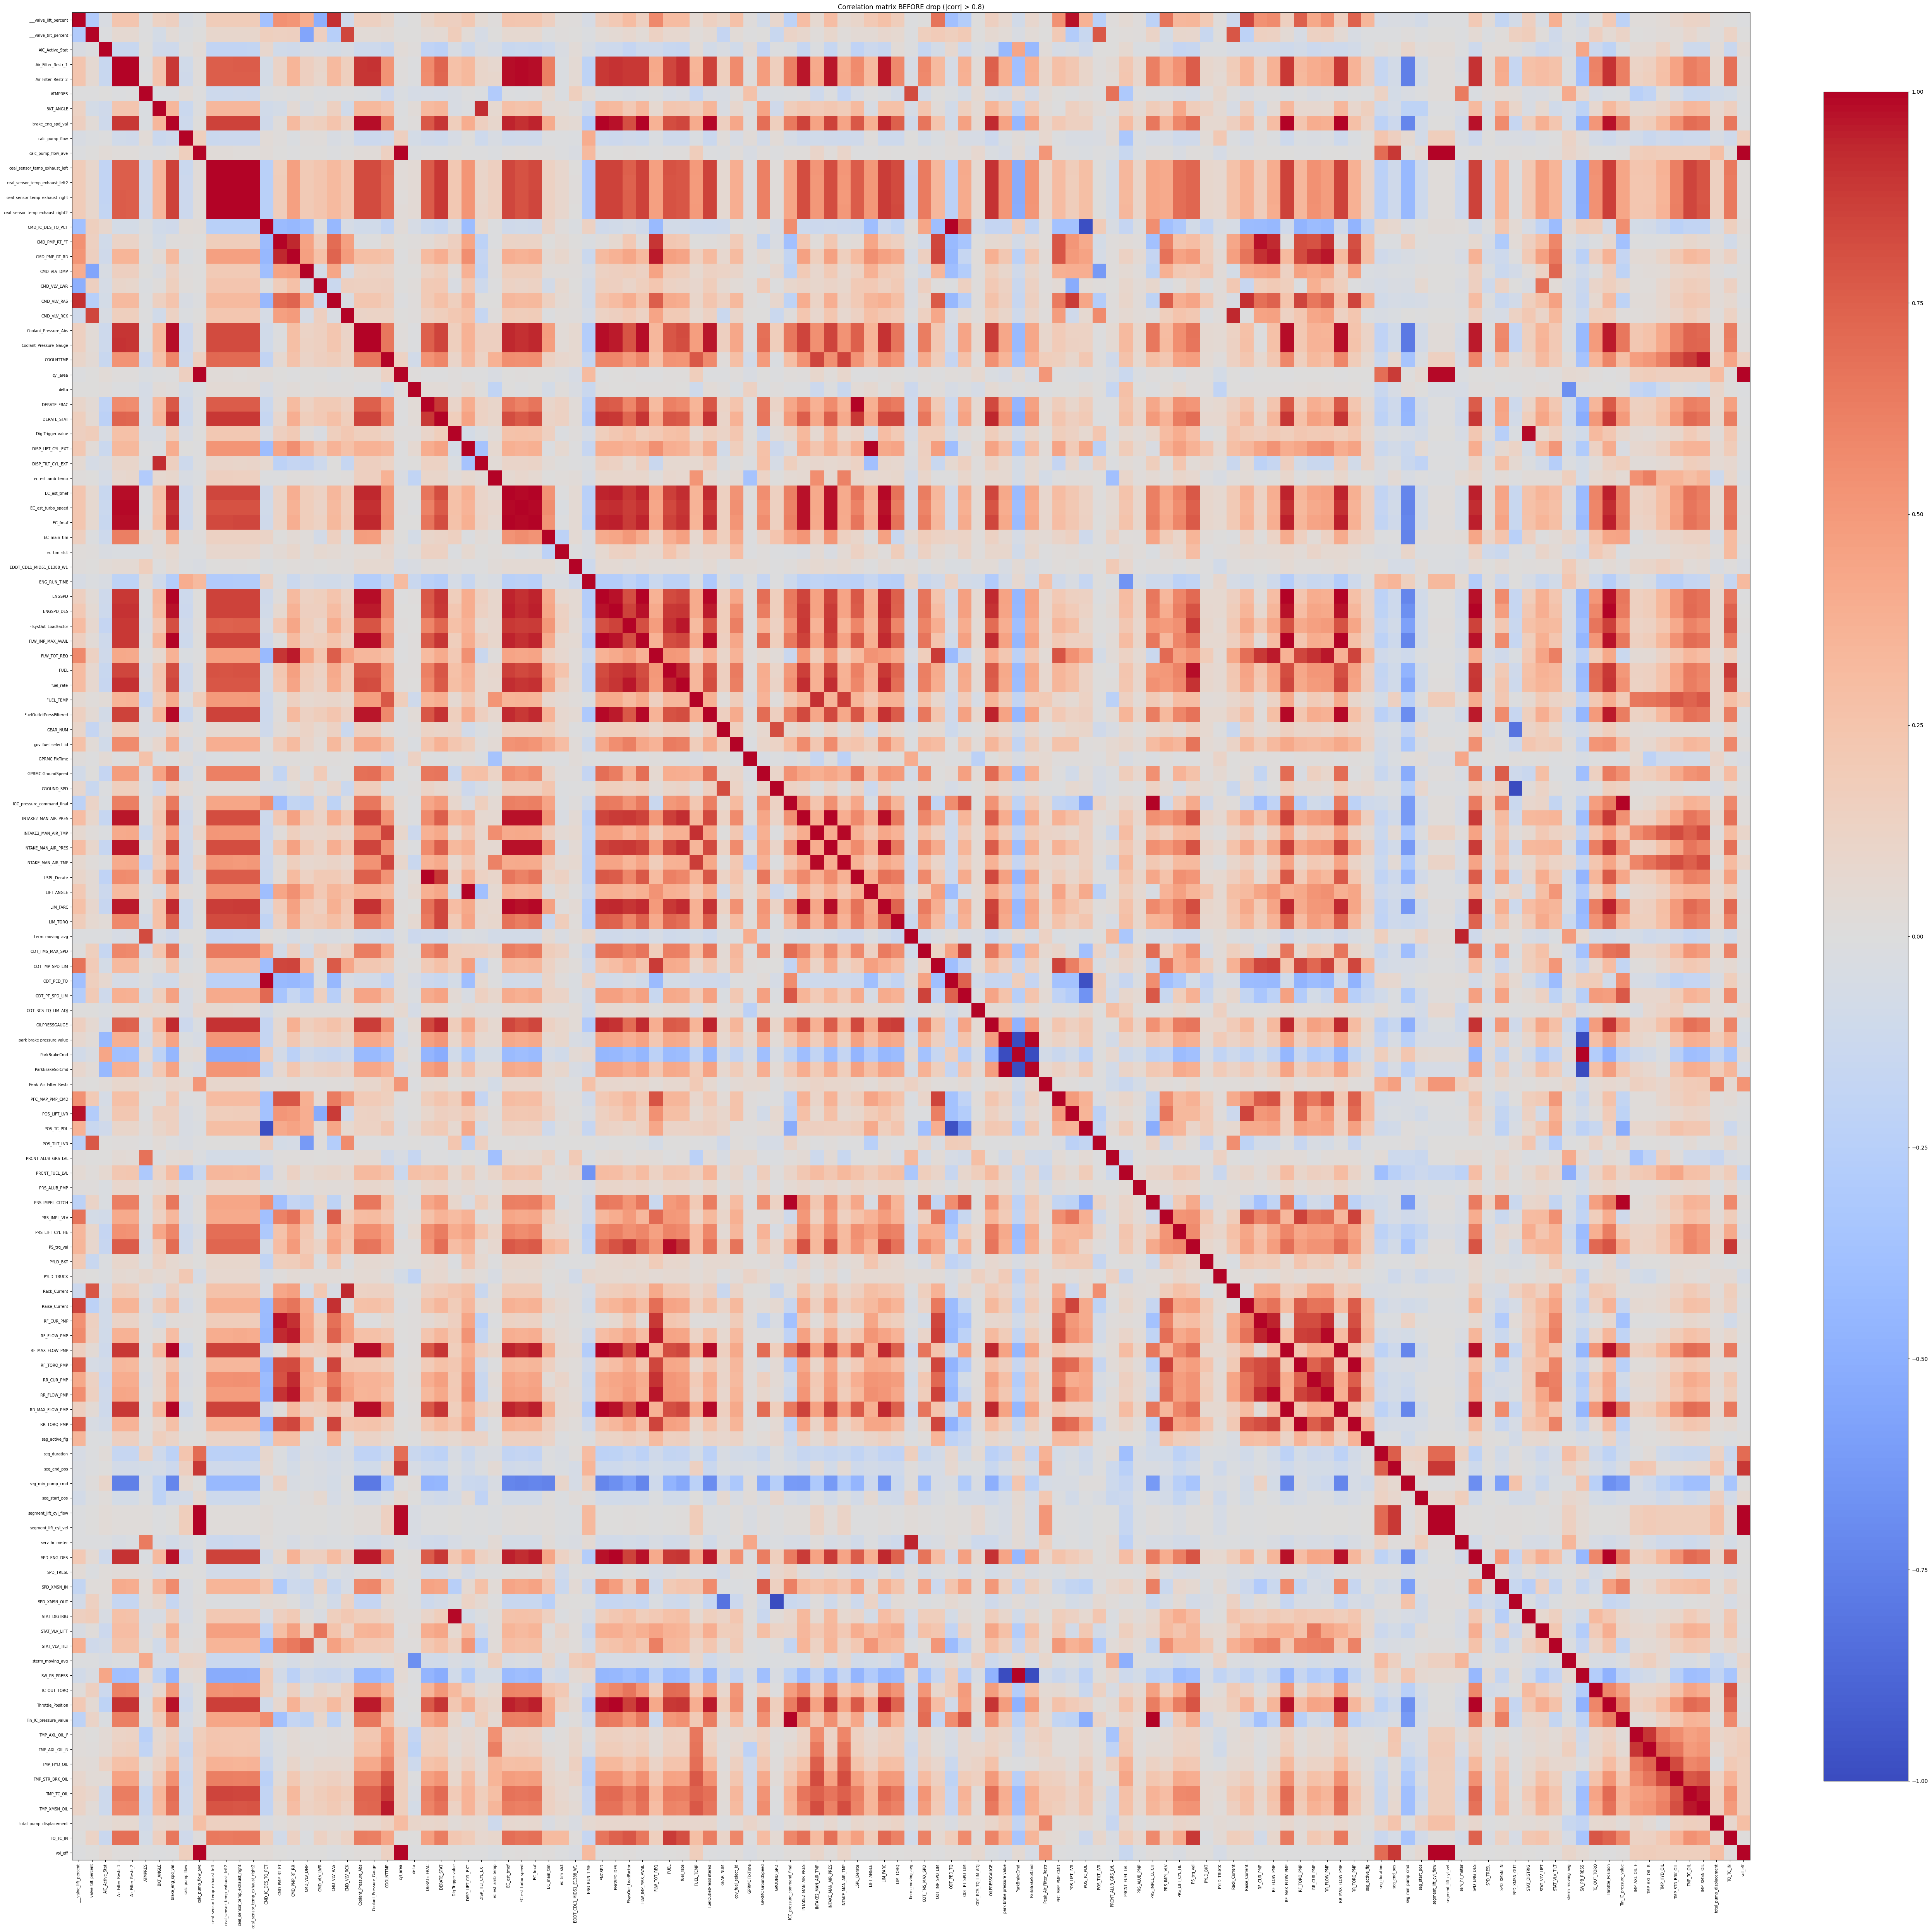


Shape before: (127 cols)  ->  after: (60 cols)


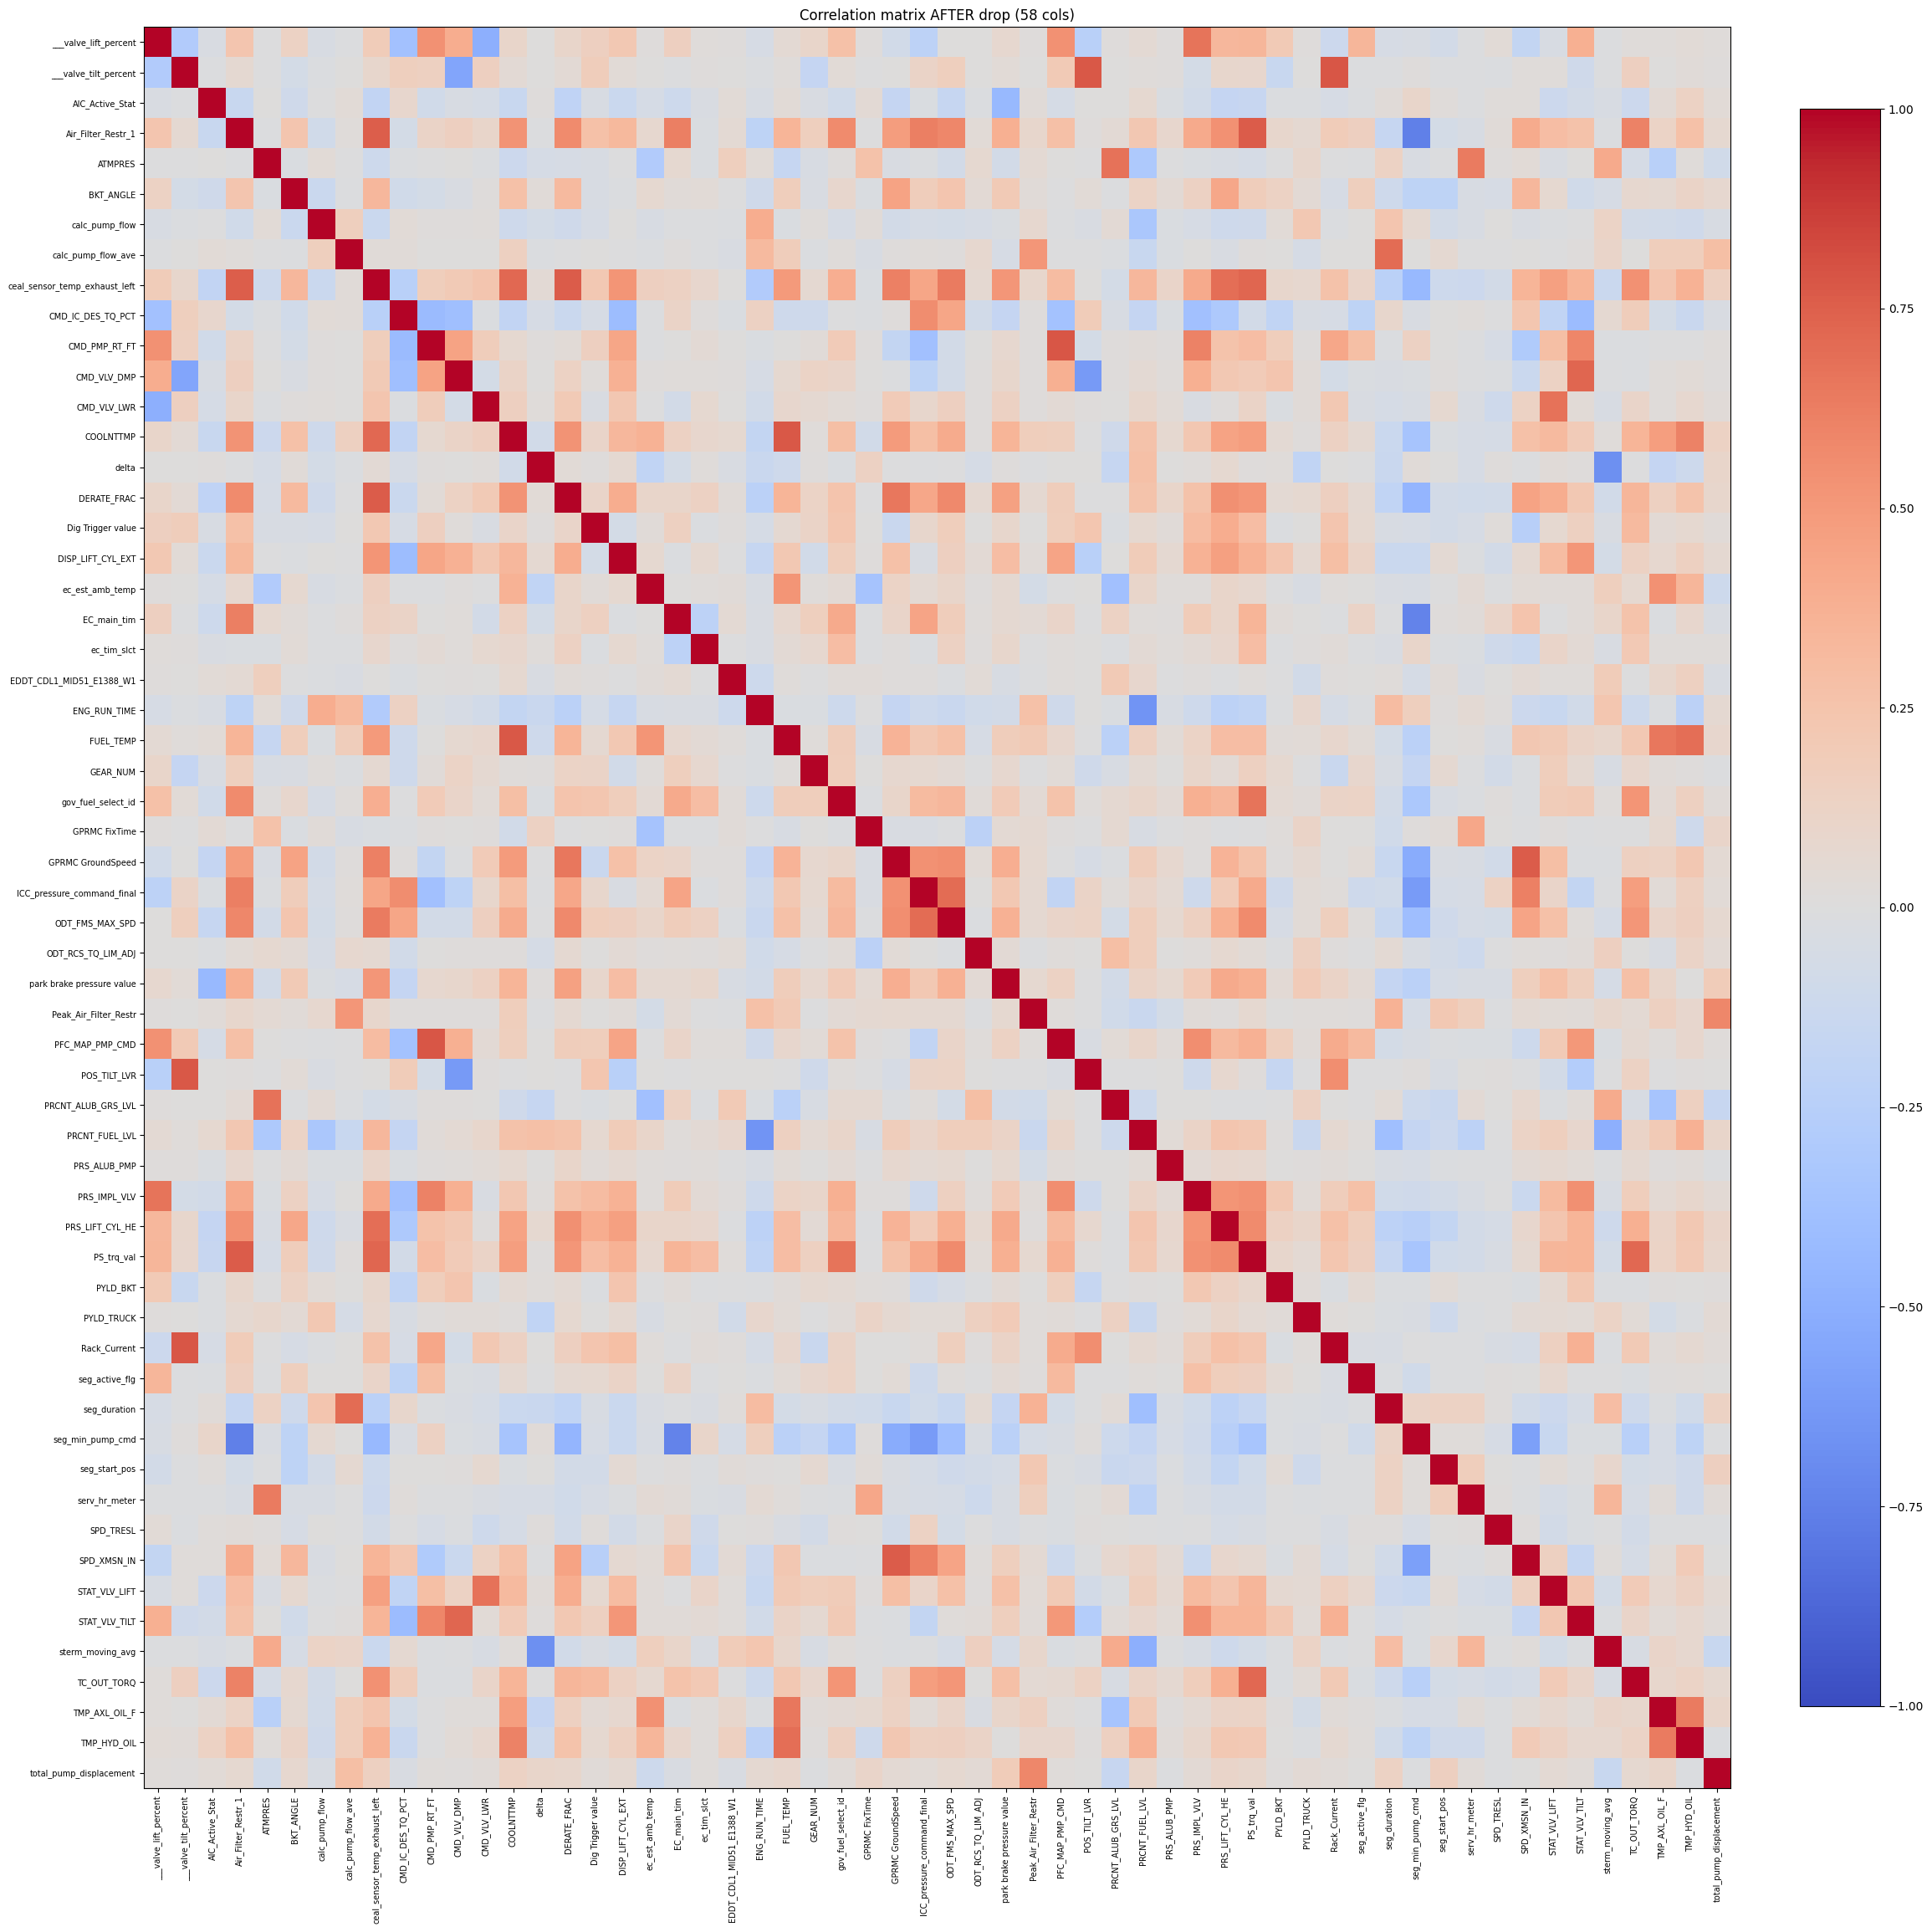

,removed_variable,kept_variable,abs_corr,signed_corr
0,lterm_moving_avg,ATMPRES,0.822846,0.822846
1,Air_Filter_Restr_2,Air_Filter_Restr_1,0.997484,0.997484
2,Coolant_Pressure_Abs,Air_Filter_Restr_1,0.898379,0.898379
3,Coolant_Pressure_Gauge,Air_Filter_Restr_1,0.899199,0.899199
4,EC_est_tmef,Air_Filter_Restr_1,0.979606,0.979606
...,...,...,...,...
62,ceal_sensor_temp_exhaust_right,ceal_sensor_temp_exhaust_left,0.999518,0.999518
63,ceal_sensor_temp_exhaust_right2,ceal_sensor_temp_exhaust_left,0.999494,0.999494
64,ParkBrakeCmd,park brake pressure value,0.999164,-0.999164
65,ParkBrakeSolCmd,park brake pressure value,0.999164,0.999164


In [13]:
# Correlation analysis: drop variables with |corr| > threshold (covers + and -).
# Kept columns keep their original name. The mapping of removed -> kept variable
# is stored in a dict and exported as CSV for backtracking.
CORR_THRESHOLD = 0.80

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_signed = df[numeric_cols].corr()
corr_matrix = corr_signed.abs()

# Upper triangle (excluding the diagonal) for reporting
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
upper_signed = corr_signed.where(np.triu(np.ones(corr_signed.shape, dtype=bool), k=1))

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "var_1", "level_1": "var_2", 0: "abs_corr"})
         .query("abs_corr > @CORR_THRESHOLD")
         .assign(signed_corr=lambda x: [
             upper_signed.loc[r.var_1, r.var_2] for r in x.itertuples()
         ])
         .sort_values("abs_corr", ascending=False)
         .reset_index(drop=True)
)

# Greedy pass: for each column, if it correlates above threshold with an
# earlier still-kept column, drop it and record the keeper -> [dropped] mapping.
dropped = set()
absorbed = {}        # keeper_col -> [dropped_cols]   (one keeper, many absorbed)
removed_to_kept = {} # dropped_col -> keeper_col      (flat reverse lookup)

for j_idx, col_j in enumerate(numeric_cols):
    keeper = None
    for i_idx in range(j_idx):
        col_i = numeric_cols[i_idx]
        if col_i in dropped:
            continue
        if corr_matrix.iat[i_idx, j_idx] > CORR_THRESHOLD:
            keeper = col_i
            break
    if keeper is not None:
        dropped.add(col_j)
        absorbed.setdefault(keeper, []).append(col_j)
        removed_to_kept[col_j] = keeper

cols_to_drop = list(dropped)

print(f"Pairs with |corr| > {CORR_THRESHOLD}: {len(high_corr_pairs)}")
if not high_corr_pairs.empty:
    print(high_corr_pairs.to_string(index=False))

print(f"\nColumns to drop ({len(cols_to_drop)}):")
for c in cols_to_drop:
    print(f"  - {c}  ->  kept: {removed_to_kept[c]}")

# Build a tidy DataFrame with the mapping and export to CSV
mapping_df = pd.DataFrame(
    [{"removed_variable": r,
      "kept_variable": k,
      "abs_corr": float(corr_matrix.loc[r, k]),
      "signed_corr": float(corr_signed.loc[r, k])}
     for r, k in removed_to_kept.items()]
).sort_values(["kept_variable", "removed_variable"]).reset_index(drop=True)

mapping_csv = f"{SERIAL_NUMBER}_corr_drop_mapping.csv"
mapping_df.to_csv(mapping_csv, index=False)
print(f"\nMapping exported to: {mapping_csv}  ({len(mapping_df)} rows)")

# Heatmap of the SIGNED correlation matrix BEFORE dropping (-1 to 1)
fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(numeric_cols)),
                                max(5, 0.4 * len(numeric_cols))))
im = ax.imshow(corr_signed.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90, fontsize=7)
ax.set_yticklabels(numeric_cols, fontsize=7)
ax.set_title(f"Correlation matrix BEFORE drop (|corr| > {CORR_THRESHOLD})")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Drop redundant columns (keepers retain their ORIGINAL names)
before = df.shape[1]
df = df.drop(columns=cols_to_drop)
print(f"\nShape before: ({before} cols)  ->  after: ({df.shape[1]} cols)")

# Heatmap of the SIGNED correlation matrix AFTER dropping
remaining_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_after = df[remaining_cols].corr()

fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(remaining_cols)),
                                max(5, 0.4 * len(remaining_cols))))
im = ax.imshow(corr_after.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(remaining_cols)))
ax.set_yticks(range(len(remaining_cols)))
ax.set_xticklabels(remaining_cols, rotation=90, fontsize=7)
ax.set_yticklabels(remaining_cols, fontsize=7)
ax.set_title(f"Correlation matrix AFTER drop ({len(remaining_cols)} cols)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

mapping_df


### 4 - Principal Component Analysis (PCA) - 90%
After the variance / correlation I still belive there might still be a lot of channels. PCA gives us a compact, orthogonal representation of the
remaining numeric features. We standardize first so every channel contributes
on the same scale.


PCA input matrix: (1257373, 58)  (58 features)
Components for 80% variance: 30 / 58


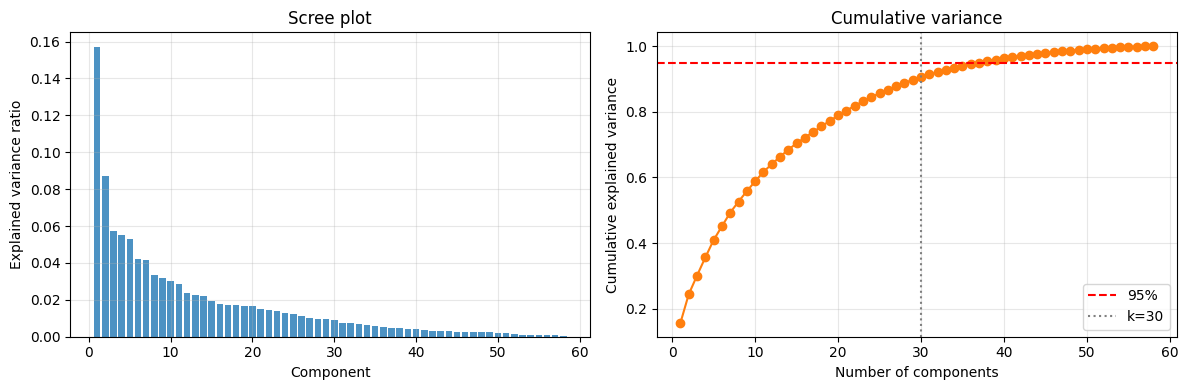


Top 10 contributors to PC1 (by |loading|):
ceal_sensor_temp_exhaust_left    0.304759
Air_Filter_Restr_1               0.280997
PS_trq_val                       0.267109
DERATE_FRAC                      0.248553
COOLNTTMP                        0.239774
PRS_LIFT_CYL_HE                  0.239366
ODT_FMS_MAX_SPD                  0.213672
GPRMC GroundSpeed                0.196419
seg_min_pump_cmd                 0.185834
TC_OUT_TORQ                      0.184941

Top 10 contributors to PC2 (by |loading|):
CMD_PMP_RT_FT                 0.342604
ICC_pressure_command_final    0.312441
STAT_VLV_TILT                 0.289052
CMD_IC_DES_TQ_PCT             0.287913
CMD_VLV_DMP                   0.278379
___valve_lift_percent         0.276290
PFC_MAP_PMP_CMD               0.272243
PRS_IMPL_VLV                  0.262211
SPD_XMSN_IN                   0.258503
GPRMC GroundSpeed             0.193498


C:\Users\alvarjl3\AppData\Local\Temp\ipykernel_15436\621376630.py:77: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\alvarjl3\Documents\Repos\Downtime_Analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


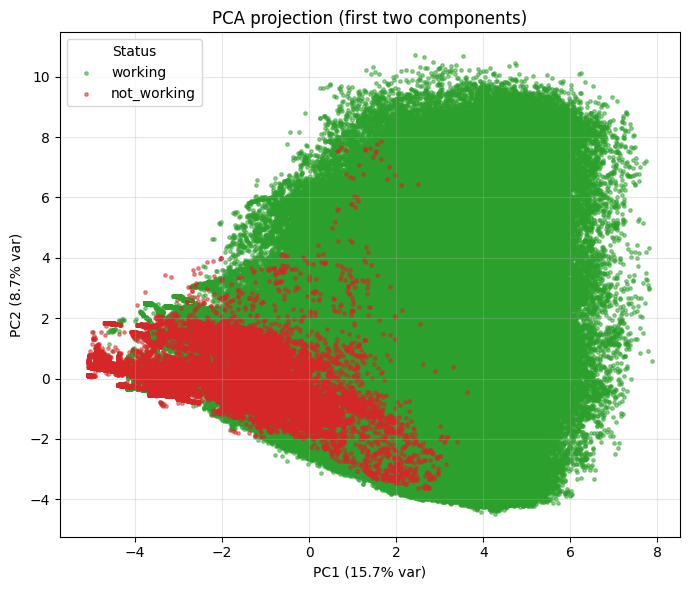


Saved: M9P00224_PCA_scores.parquet  ((1257373, 30))
Saved: M9P00224_PCA_loadings.csv  ((58, 30))


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1. Build the numeric feature matrix (skip protected/target columns)
numeric_cols_pca = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in PROTECTED_COLS
]
X = df[numeric_cols_pca].dropna()
print(f"PCA input matrix: {X.shape}  ({len(numeric_cols_pca)} features)")

# --- 2. Standardize
X_std = StandardScaler().fit_transform(X)

# --- 3. Fit full PCA to inspect the spectrum
pca_full = PCA().fit(X_std)
explained = pca_full.explained_variance_ratio_
cum = np.cumsum(explained)

# Number of components needed to reach 80% variance
k = int(np.searchsorted(cum, 0.9) + 1)
print(f"Components for 80% variance: {k} / {len(explained)}")

# --- 4. Scree + cumulative variance plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(range(1, len(explained) + 1), explained, color="tab:blue", alpha=0.8)
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Explained variance ratio")
ax[0].set_title("Scree plot")
ax[0].grid(True, alpha=0.3)

ax[1].plot(range(1, len(cum) + 1), cum, marker="o", color="tab:orange")
ax[1].axhline(0.95, color="red", linestyle="--", label="95%")
ax[1].axvline(k, color="gray", linestyle=":", label=f"k={k}")
ax[1].set_xlabel("Number of components")
ax[1].set_ylabel("Cumulative explained variance")
ax[1].set_title("Cumulative variance")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5. Refit with k components and project
pca = PCA(n_components=k)
scores = pca.fit_transform(X_std)
pc_cols = [f"PC{i+1}" for i in range(k)]
scores_df = pd.DataFrame(scores, columns=pc_cols, index=X.index)

# --- 6. Loadings (contribution of each original feature to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_cols_pca,
    columns=pc_cols,
)

print("\nTop 10 contributors to PC1 (by |loading|):")
print(loadings["PC1"].abs().sort_values(ascending=False).head(10).to_string())
print("\nTop 10 contributors to PC2 (by |loading|):")
print(loadings["PC2"].abs().sort_values(ascending=False).head(10).to_string())

# --- 7. 2D scatter of the first two PCs, coloured by Status (target)
fig, ax = plt.subplots(figsize=(7, 6))
status_vals = df.loc[X.index, "Status"]
palette = {"working": "tab:green", "not_working": "tab:red"}
for lvl, c in palette.items():
    m = status_vals == lvl
    if m.any():
        ax.scatter(scores_df.loc[m, "PC1"], scores_df.loc[m, "PC2"],
                   s=6, alpha=0.5, color=c, label=lvl)
ax.legend(title="Status")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
ax.set_title("PCA projection (first two components)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. Persist the PCA scores + loadings for downstream use
scores_out   = f"{SERIAL_NUMBER}_PCA_scores.parquet"
loadings_out = f"{SERIAL_NUMBER}_PCA_loadings.csv"
scores_df.to_parquet(scores_out, index=False)
loadings.to_csv(loadings_out)
print(f"\nSaved: {scores_out}  ({scores_df.shape})")
print(f"Saved: {loadings_out}  ({loadings.shape})")


### Final - Save df to parquet for modeling stage
Remianing features df and PCA df will be available as parquets for the following stages

In [15]:
# Filtered raw features
features_file = f"{SERIAL_NUMBER}_Features.parquet"
df.to_parquet(features_file, index=False)
print(f"Parquet exported: {features_file}   shape={df.shape}")

# PCA features (only if the PCA cell ran and produced `scores_df`)
try:
    extra_cols = [c for c in ("Status", "date_time") if c in df.columns]
    pca_df = pd.concat(
        [df.loc[scores_df.index, extra_cols].reset_index(drop=True),
         scores_df.reset_index(drop=True)],
        axis=1,
    )
    pca_file = f"{SERIAL_NUMBER}_PCA_Features.parquet"
    pca_df.to_parquet(pca_file, index=False)
    print(f"Parquet exported: {pca_file}   shape={pca_df.shape}")
except NameError:
    print("PCA scores not found in memory (run the PCA cell first to also "
          "export the PCA-features parquet).")


Parquet exported: M9P00224_Features.parquet   shape=(1257373, 60)
Parquet exported: M9P00224_PCA_Features.parquet   shape=(1257373, 31)


In [16]:
df

,GLOBAL_TIME,___valve_lift_percent,___valve_tilt_percent,AIC_Active_Stat,Air_Filter_Restr_1,ATMPRES,BKT_ANGLE,calc_pump_flow,calc_pump_flow_ave,ceal_sensor_temp_exhaust_left,...,SPD_TRESL,SPD_XMSN_IN,STAT_VLV_LIFT,STAT_VLV_TILT,sterm_moving_avg,TC_OUT_TORQ,TMP_AXL_OIL_F,TMP_HYD_OIL,total_pump_displacement,Status
0,2026-02-01 00:00:00.029001,0.0,0.0,0.0,1.59375,99.78125,42.041754,705751.0,53919.0,553.4375,...,2010.0,953.875,0.0,0.0,64428.0,2027.0,54.750000,60.871084,32512.0,working
1,2026-02-01 00:00:00.149000,0.0,0.0,0.0,1.50000,99.78125,42.018315,705751.0,53919.0,553.4375,...,2010.0,947.250,0.0,0.0,64428.0,2004.0,54.750000,60.871084,32512.0,working
2,2026-02-01 00:00:00.269000,0.0,0.0,0.0,1.50000,99.78125,42.002689,705751.0,53919.0,553.4375,...,2010.0,981.000,0.0,0.0,64428.0,1952.0,54.750000,60.871084,32512.0,working
3,2026-02-01 00:00:00.389000,0.0,0.0,0.0,1.50000,99.78125,42.018315,705751.0,53919.0,551.3125,...,2010.0,1012.125,0.0,0.0,64428.0,1874.0,54.750000,60.871084,32512.0,working
4,2026-02-01 00:00:00.508999,0.0,0.0,0.0,1.50000,99.78125,42.049567,705751.0,53919.0,551.3125,...,2010.0,1028.875,0.0,0.0,64428.0,1831.0,54.750000,60.871084,32512.0,working
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1257368,2026-02-03 23:06:25.033000,0.0,0.0,0.0,0.00000,101.09375,-6.070701,53943.0,52585.0,230.0000,...,2010.0,0.000,0.0,0.0,64451.0,0.0,67.992188,68.738775,31440.0,not_working
1257369,2026-02-03 23:06:25.153000,0.0,0.0,0.0,0.00000,101.09375,-6.070701,53943.0,52585.0,230.0000,...,2010.0,0.000,0.0,0.0,64451.0,0.0,67.992188,68.738775,31440.0,not_working
1257370,2026-02-03 23:06:25.273000,0.0,0.0,0.0,0.00000,101.09375,-6.070701,53943.0,52585.0,230.0000,...,2010.0,0.000,0.0,0.0,64451.0,0.0,67.992188,68.738775,31440.0,not_working
1257371,2026-02-03 23:06:25.392999,0.0,0.0,0.0,0.00000,101.09375,-6.070701,53943.0,52585.0,230.0000,...,2010.0,0.000,0.0,0.0,64451.0,0.0,67.992188,68.738775,31440.0,not_working


In [17]:
pca_df

,Status,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30
0,working,2.053790,-1.956135,-2.105974,-1.351835,0.938921,-1.269910,0.788119,-0.083948,0.450629,...,-1.276063,0.647610,0.523206,-0.343615,0.384615,0.054667,1.281060,-0.457727,0.191978,1.412972
1,working,2.079874,-2.067431,-2.472920,-1.647008,1.098066,-1.563494,0.522141,-0.997969,1.276672,...,-0.983132,1.320464,0.615848,0.502076,-0.113000,0.114503,-0.130587,-0.438585,-0.129219,1.006943
2,working,2.059079,-2.066179,-2.509158,-1.671718,1.104911,-1.497605,0.528273,-0.994630,1.317561,...,-0.928604,1.326041,0.627314,0.493237,-0.120569,0.115795,-0.132282,-0.429395,-0.115600,0.997500
3,working,2.022136,-2.061106,-2.512867,-1.696892,1.096309,-1.475007,0.522559,-0.979084,1.332060,...,-0.917531,1.304194,0.601904,0.492451,-0.137643,0.152241,-0.130860,-0.398978,-0.112373,0.980038
4,working,1.958648,-2.067073,-2.538435,-1.727324,1.102495,-1.427063,0.528224,-0.980398,1.330722,...,-0.888608,1.281721,0.590222,0.472963,-0.163165,0.170570,-0.139119,-0.392237,-0.122588,0.970056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1257368,not_working,-2.854816,-0.249044,-0.865893,-1.940352,1.574168,-1.293036,-1.496666,1.844612,-2.191281,...,-0.645743,-1.523501,0.231245,0.320039,0.880105,1.101119,-0.547957,-0.612348,0.301459,0.283856
1257369,not_working,-2.855057,-0.249004,-0.865768,-1.940505,1.574306,-1.293254,-1.496457,1.844877,-2.191230,...,-0.645048,-1.522838,0.231607,0.319754,0.880686,1.101073,-0.547594,-0.612343,0.301284,0.283755
1257370,not_working,-2.855541,-0.248971,-0.865843,-1.940516,1.574296,-1.293563,-1.497101,1.845285,-2.191550,...,-0.645374,-1.522774,0.231450,0.320266,0.880542,1.101173,-0.547596,-0.612324,0.301695,0.284267
1257371,not_working,-2.855089,-0.249001,-0.865769,-1.940509,1.574309,-1.293276,-1.496486,1.844905,-2.191246,...,-0.645047,-1.522817,0.231608,0.319774,0.880693,1.101077,-0.547585,-0.612341,0.301301,0.283779


## Conclusions

- **Target variable.** Using the GPS-based area segmentation we obtained a clean binary `Status` label (`working` / `not_working`) and protected it (along with `date_time` / `GLOBAL_TIME`) from being eliminated by the downstream filters. Concerns regarding `Keyswitch` confirmed the labels are consistent with the ignition state, which gives us a reasonable baseline target for supervised models.

- **Feature pipeline.** The combination of missing-value pruning, zero-/low-variance removal, and a correlation filter at |r| > 0.80 reduced the channel set substantially without dropping the target. PCA on the survivors reached 95% cumulative variance with `k_95` components, and the PC1/PC2 scatter already shows visible separation between the two classes.

- **Two training datasets exported.** `*_Features.parquet` (filtered raw channels + `Status`) and `*_PCA_Features.parquet` (PC scores + `Status`) are saved side-by-side so the next stage can train and compare a model on each representation.

- **Uncertainty about the selected features.** The thresholds used here (10% missing, 1% normalized variance, 0.80 correlation, 90% PCA variance) are reasonable defaults but not validated against model performance yet. It is very likely that some informative channels were dropped (or some noisy ones kept) by the unsupervised filters.

- **Next step → iterate.** Once a few baseline models (e.g., logistic regression, random forest, gradient boosting) are trained on both parquet files, we should come back to this notebook and revisit:
  1. The numeric thresholds (variance, correlation, PCA cut-off).
  2. Whether to re-enable the ANOVA filter and use it to pre-select channels instead of manually inspecting the features variance.
  3. Whether the GPS geofence needs tuning per machine, or to be replaced by a learned classifier (Clustering?).
  4. Possibly adding other engineered features

In other words: this Avance gives us a working feature set, but the final selection should be guided by model feedback, not by the filters alone.
